In [41]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
model = ChatGoogleGenerativeAI(model='gemini-flash-latest')

In [3]:
load_dotenv()

True

In [30]:
class JokeGenStructure(BaseModel):
    joke : str = Field(description="Generated funny joke")

In [31]:
class ExpGenStruct(BaseModel):
    explanation : str = Field(description="An explanation on why the joke is funny")

In [32]:
gen_joke_llm = model.with_structured_output(JokeGenStructure)
expl_joke_llm = model.with_structured_output(ExpGenStruct)

In [33]:
class jokeState(TypedDict):
    topic : str
    joke : str
    explanation : str

In [34]:
def gen_joke(state:jokeState):
    topic = state['topic']
    prompt = f"Generate a funny , lighthearted joke about : {topic}"
    joke = gen_joke_llm.invoke(prompt)
    return {'joke':joke}

In [35]:
def gen_explanation(state:jokeState):
    joke = state['joke']
    prompt = f"Explain why this joke is funny: {joke}"
    explanation = expl_joke_llm.invoke(prompt)
    return {'explanation':explanation}
    

In [42]:
checkpointer = InMemorySaver()
graph = StateGraph(jokeState)

# add node
graph.add_node('gen_joke',gen_joke)
graph.add_node('gen_explanation',gen_explanation)

# add edge
graph.add_edge(START,'gen_joke')
graph.add_edge('gen_joke','gen_explanation')
graph.add_edge('gen_explanation',END)

# compile
workflow = graph.compile(checkpointer=checkpointer)

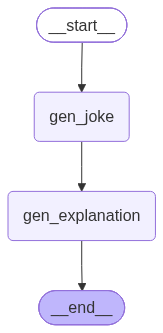

In [37]:
workflow

In [43]:
config = {'configurable':{'thread_id':"1"}}
workflow.invoke({'topic':'Narendra Modi'},config=config)

{'topic': 'Narendra Modi',
 'joke': JokeGenStructure(joke="Why does Narendra Modi never play hide and seek? Because the moment he says 'Mitron!', everybody immediately knows where he is!"),
 'explanation': ExpGenStruct(explanation="The joke is funny because it relies on the catchphrase 'Mitron' (meaning 'friends' in Hindi), which Indian Prime Minister Narendra Modi frequently uses to address the public during his speeches. In hide and seek, remaining silent is essential to avoid being found. The humor comes from the absurd premise that Modi cannot resist using his signature greeting even while hiding, thereby immediately giving away his location.")}

In [45]:
workflow.get_state(config)

Deserializing unregistered type __main__.JokeGenStructure from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'JokeGenStructure')]
Deserializing unregistered type __main__.ExpGenStruct from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ExpGenStruct')]


StateSnapshot(values={'topic': 'Narendra Modi', 'joke': JokeGenStructure(joke="Why does Narendra Modi never play hide and seek? Because the moment he says 'Mitron!', everybody immediately knows where he is!"), 'explanation': ExpGenStruct(explanation="The joke is funny because it relies on the catchphrase 'Mitron' (meaning 'friends' in Hindi), which Indian Prime Minister Narendra Modi frequently uses to address the public during his speeches. In hide and seek, remaining silent is essential to avoid being found. The humor comes from the absurd premise that Modi cannot resist using his signature greeting even while hiding, thereby immediately giving away his location.")}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1970e4-0814-6f33-8002-d41446397e55'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-13T11:58:09.274643+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': 

In [46]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Narendra Modi', 'joke': JokeGenStructure(joke="Why does Narendra Modi never play hide and seek? Because the moment he says 'Mitron!', everybody immediately knows where he is!"), 'explanation': ExpGenStruct(explanation="The joke is funny because it relies on the catchphrase 'Mitron' (meaning 'friends' in Hindi), which Indian Prime Minister Narendra Modi frequently uses to address the public during his speeches. In hide and seek, remaining silent is essential to avoid being found. The humor comes from the absurd premise that Modi cannot resist using his signature greeting even while hiding, thereby immediately giving away his location.")}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1970e4-0814-6f33-8002-d41446397e55'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-13T11:58:09.274643+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id':

In [39]:
initial_state={'topic':'Narendra Modi'}
result = workflow.invoke(initial_state)
print(result)

{'topic': 'Narendra Modi', 'joke': JokeGenStructure(joke='Why is Narendra Modi terrible at playing hide-and-seek? Because as soon as he hides, he says, "Mitron!" and gives away his position!'), 'explanation': ExpGenStruct(explanation='This joke is funny because "Mitron!" (meaning "Friends!" in Hindi) is a famous catchphrase frequently used by Narendra Modi, the Prime Minister of India, to address the public in his speeches. The humor comes from applying his irresistible habit of shouting his iconic greeting to the game of hide-and-seek, where remaining completely quiet is essential.')}


In [40]:
print(result['topic'])
print(result['joke'])
print(result['explanation'])

Narendra Modi
joke='Why is Narendra Modi terrible at playing hide-and-seek? Because as soon as he hides, he says, "Mitron!" and gives away his position!'
explanation='This joke is funny because "Mitron!" (meaning "Friends!" in Hindi) is a famous catchphrase frequently used by Narendra Modi, the Prime Minister of India, to address the public in his speeches. The humor comes from applying his irresistible habit of shouting his iconic greeting to the game of hide-and-seek, where remaining completely quiet is essential.'


In [47]:
config2 = {'configurable':{'thread_id':"2"}}
workflow.invoke({'topic':'Mahatma Gandhi'},config=config2)

{'topic': 'Mahatma Gandhi',
 'joke': JokeGenStructure(joke="What was Mahatma Gandhi's favorite type of tea? Civili-tea!"),
 'explanation': ExpGenStruct(explanation="The joke is a pun that plays on the word civility and civil disobedience, which are core concepts of Mahatma Gandhi's philosophy of nonviolent resistance, while cleverly modifying the word to end in -tea to answer the question.")}

In [48]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Mahatma Gandhi', 'joke': JokeGenStructure(joke="What was Mahatma Gandhi's favorite type of tea? Civili-tea!"), 'explanation': ExpGenStruct(explanation="The joke is a pun that plays on the word civility and civil disobedience, which are core concepts of Mahatma Gandhi's philosophy of nonviolent resistance, while cleverly modifying the word to end in -tea to answer the question.")}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1970ed-5ca2-682d-8002-43d66a05a9a3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-13T12:02:19.732750+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1970ed-3678-6e1e-8001-723280587e1b'}}, tasks=(), interrupts=())

In [49]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Mahatma Gandhi', 'joke': JokeGenStructure(joke="What was Mahatma Gandhi's favorite type of tea? Civili-tea!"), 'explanation': ExpGenStruct(explanation="The joke is a pun that plays on the word civility and civil disobedience, which are core concepts of Mahatma Gandhi's philosophy of nonviolent resistance, while cleverly modifying the word to end in -tea to answer the question.")}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1970ed-5ca2-682d-8002-43d66a05a9a3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-13T12:02:19.732750+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1970ed-3678-6e1e-8001-723280587e1b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Mahatma Gandhi', 'joke': JokeGenStructure(joke="What was Mahatma Gandhi's favorite type of tea? Civili-tea!")}, next=('gen_explanation',), config={'configurable

In [51]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Narendra Modi', 'joke': JokeGenStructure(joke="Why does Narendra Modi never play hide and seek? Because the moment he says 'Mitron!', everybody immediately knows where he is!"), 'explanation': ExpGenStruct(explanation="The joke is funny because it relies on the catchphrase 'Mitron' (meaning 'friends' in Hindi), which Indian Prime Minister Narendra Modi frequently uses to address the public during his speeches. In hide and seek, remaining silent is essential to avoid being found. The humor comes from the absurd premise that Modi cannot resist using his signature greeting even while hiding, thereby immediately giving away his location.")}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1970e4-0814-6f33-8002-d41446397e55'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-13T11:58:09.274643+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id':

Time Travel

In [52]:
workflow.get_state({'configurable':{'thread_id':"1","checkpoint_id":"1f1970e3-69c3-6858-8000-4910ff934694"}})

StateSnapshot(values={'topic': 'Narendra Modi'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1970e3-69c3-6858-8000-4910ff934694'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-13T11:57:52.673975+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1970e3-6995-6ad0-bfff-565ed82a83c6'}}, tasks=(PregelTask(id='4b0f1bb0-2677-bdfb-e848-d0362d8c2537', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result={'joke': JokeGenStructure(joke="Why does Narendra Modi never play hide and seek? Because the moment he says 'Mitron!', everybody immediately knows where he is!")}),), interrupts=())

In [53]:
workflow.invoke(None,{'configurable':{'thread_id':"1","checkpoint_id":"1f1970e3-69c3-6858-8000-4910ff934694"}})

{'topic': 'Narendra Modi',
 'joke': JokeGenStructure(joke="Why does Narendra Modi make a great fitness coach? Because whenever you feel like giving up, he looks at you and says, 'Mitron, one more rep!'"),
 'explanation': ExpGenStruct(explanation="The joke is funny because it humorously combines Indian Prime Minister Narendra Modi's iconic signature catchphrase 'Mitron' (meaning 'friends'), which he frequently uses to address crowds in his public speeches, with the typical motivational line used by a fitness trainer ('one more rep'). Juxtaposing a famous political greeting with gym culture creates an unexpected and amusing image.")}

In [55]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Narendra Modi', 'joke': JokeGenStructure(joke="Why does Narendra Modi make a great fitness coach? Because whenever you feel like giving up, he looks at you and says, 'Mitron, one more rep!'"), 'explanation': ExpGenStruct(explanation="The joke is funny because it humorously combines Indian Prime Minister Narendra Modi's iconic signature catchphrase 'Mitron' (meaning 'friends'), which he frequently uses to address crowds in his public speeches, with the typical motivational line used by a fitness trainer ('one more rep'). Juxtaposing a famous political greeting with gym culture creates an unexpected and amusing image.")}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19710d-9d45-67e0-8003-2c1f017204e0'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-13T12:16:45.503847+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19710d-63f0-62

Updating State

In [57]:
workflow.update_state({'configurable':{'thread_id':"1","checkpoint_id":"1f1970e3-69c3-6858-8000-4910ff934694",'checkpoint_ns':""}},{'topic':'Muslim'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f197116-0e44-6125-8001-2a3a4cefd2c4'}}

In [58]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Muslim'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197116-0e44-6125-8001-2a3a4cefd2c4'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-13T12:20:32.100547+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1970e3-69c3-6858-8000-4910ff934694'}}, tasks=(PregelTask(id='9202a538-1475-cc4f-4343-aab215319e14', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Narendra Modi', 'joke': JokeGenStructure(joke="Why does Narendra Modi make a great fitness coach? Because whenever you feel like giving up, he looks at you and says, 'Mitron, one more rep!'"), 'explanation': ExpGenStruct(explanation="The joke is funny because it humorously combines Indian Prime Minister Narendra Modi's iconic signature catchphrase 'Mitron' (me

In [60]:
workflow.invoke(None,{'configurable':{'thread_id':"1","checkpoint_id":"1f197116-0e44-6125-8001-2a3a4cefd2c4"}})

{'topic': 'Muslim',
 'joke': JokeGenStructure(joke="What's a Muslim family's favorite kind of tea to serve guests? Hospi-tea!"),
 'explanation': ExpGenStruct(explanation="This joke relies on a pun combining the word 'hospitality'—a highly valued tradition of warmth and generosity toward guests in Muslim culture—with 'tea'. The wordplay turns 'hospitality' into 'Hospi-tea', making it sound like a special beverage served to visitors.")}

In [61]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Muslim', 'joke': JokeGenStructure(joke="What's a Muslim family's favorite kind of tea to serve guests? Hospi-tea!"), 'explanation': ExpGenStruct(explanation="This joke relies on a pun combining the word 'hospitality'—a highly valued tradition of warmth and generosity toward guests in Muslim culture—with 'tea'. The wordplay turns 'hospitality' into 'Hospi-tea', making it sound like a special beverage served to visitors.")}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19711b-4abc-6d1c-8003-57468c2b780c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-13T12:22:52.659172+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19711b-2333-62b5-8002-38e408da7414'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Muslim', 'joke': JokeGenStructure(joke="What's a Muslim family's favorite kind of tea to serve guests? Hospi-tea!")},